# Air topology in a physical T–Ω CLN

**Status: native implementation and self-review completed; independent scientific candidate review pending.** This notebook uses a source-break terminal port in a perfectly conducting enclosure. Air has exactly zero conductivity. The CLN comes from the actual terminal excitation and total magnetic energy, rather than fitted frequency samples. This is Stage C1; a multiply connected conducting washer is a separate Stage C2 task.

A conductor linking the return enclosure leaves one independent circulation in the air. Writing the air field only as a single-valued scalar gradient would remove the terminal-current channel. A normalized cohomology generator supplies that channel. This topology concerns the magnetic field in the air, even when the conductor itself is simply connected.

## Current port and natural scalar correction

On the air mesh, the Gmsh-free `radia.cohomology` API gives a closed edge cochain $h$ with unit circulation. The coupled magnetic field satisfies
\[
\nabla\times H=J\quad\text{in the conductor},\qquad
\nabla\times H=0\quad\text{in air},\qquad
\oint_{\gamma}H\cdot dl=I.
\]
The air field can therefore be expressed as $Ih+\nabla\Omega$. The enclosure condition is **natural zero normal magnetic flux**, not a prescribed scalar potential. A free global gradient correction minimizes total $\int\mu |H|^2$ and enforces its discrete weak divergence/interface/outer-boundary conditions. Constants in the scalar potential are gauge freedoms.

The implementation is a curl-constrained realization of T–Ω. It keeps the closed exterior field space, including its absolute cohomology, then eliminates all global scalar gradients by magnetic-energy minimization. A Radia generator is used in the actual unit-current basis lift. No air conductivity, artificial epsilon inverse, or tangential-zero magnetic field is introduced. Only conductor curl enters Joule loss; the entire conductor and air field enters magnetic energy.

The original small export permits a checker to reconstruct this space from the raw air-curl and gradient matrices. On the actual mesh, the air period functional equals the conductor terminal-work functional. Removing the linked period clamps all net terminal current: it does not produce a valid alternative finite impedance.

In matrix notation the admissibility condition is `air_curl @ Q = 0`. The scalar elimination gives `G.T @ L @ Q = 0`; it is **not** the Euclidean constraint `G.T @ Q = 0`. The latter would discard valid physical fields.

In [1]:
from pathlib import Path
import json, sys, numpy as np
import matplotlib.pyplot as plt
root = Path.cwd().parent if Path.cwd().name == "docs" else Path.cwd()
sys.path.insert(0, str(root / "validation"))
from cohomology_matrix_check import check
from validate_tomega_air import main as validate
record = json.loads((root / "docs/data/tomega_air.json").read_text())
small = json.loads((root / "docs/data/tomega_air_matrices.json").read_text())
validate()
print(check(small))
print("Recorded native runtime:", small["runtime"])

PASS cohomology current periods, original small matrices, eight-element contact and disclosed refinement


{'current_dimension': 27, 'independent_space_gap': 2.2715678547452582e-15}
Recorded native runtime: {'numpy': '2.5.2', 'scipy': '1.17.1', 'ngsolve': '6.2.2607', 'netgen-mesher': '6.2.2607', 'radia': '5.2.3', 'python': '3.12.10'}


## The same energy recurrence

Let $R$ be conductor Joule loss, $L$ total magnetic energy, and $b^Tj$ terminal current. The full terminal impedance is
\[
Z(s)=\frac{1}{b^T(R+sL)^{-1}b}.
\]
For expansion point $s_0\ge0$, set $M_0=R+s_0L$ and $j_0=M_0^{-1}b$. At each physical stage,
\[
\widehat R_k=\frac{1}{j_k^TM_0j_k},\quad
x_k=x_{k-1}+\widehat R_kj_k,\quad
L_k=x_k^TLx_k,\quad
j_{k+1}=j_k-M_0^{-1}Lx_k/L_k.
\]
Each saved stage is an independent array. Four stages give eight ladder elements. The shifted branch variable is $s-s_0$; $\widehat R$ at positive shift includes both Joule loss and $s_0$ times magnetic energy. The first element is $Z(s_0)$.

The small-matrix checker reconstructs the physical fields in its own basis, both full impedances, and Taylor coefficients through order eight. The ladder and full model agree through coefficients zero to seven (contact order eight); coefficient eight is retained as the first unmatched term. The larger native cohorts are stored evidence, not full FEM reruns in CI.

In [2]:
print("Small matched mesh:", small["mesh"]["ne"], "tetrahedra;")
for run in small["runs"]:
    print("s0 =", run["s0"], "rad/s")
    for i, (r, l) in enumerate(zip(run["Rhat"], run["L"])):
        print(f"  stage {i}: Rhat={r:.6g} ohm, L={l:.6g} H")
    print("  electric/magnetic orthogonality:", run["electric_orth"], run["magnetic_orth"])
    print("  full minus projected coefficient 8:",
          run["full_Z_coefficients"][8]-run["galerkin_Z_coefficients"][8])

Small matched mesh: 118 tetrahedra;
s0 = 0.0 rad/s
  stage 0: Rhat=4.35346e-05 ohm, L=2.99739e-09 H
  stage 1: Rhat=0.00889034 ohm, L=1.37731e-07 H
  stage 2: Rhat=0.0628903 ohm, L=4.24226e-07 H
  stage 3: Rhat=0.254414 ohm, L=1.27419e-06 H
  electric/magnetic orthogonality: 1.088719689729472e-12 3.953158172212915e-12
  full minus projected coefficient 8: -3.5383849111877015e-17
s0 = 62831.853071795864 rad/s
  stage 0: Rhat=0.000229774 ohm, L=2.94562e-09 H
  stage 1: Rhat=0.0497515 ohm, L=2.85865e-07 H
  stage 2: Rhat=0.239806 ohm, L=1.0212e-06 H
  stage 3: Rhat=1.34869 ohm, L=5.91374e-06 H
  electric/magnetic orthogonality: 8.681587942387978e-16 1.2816646292246471e-15
  full minus projected coefficient 8: -5.025890582342204e-20


## A different cut changes coordinates, not the field

Two vertex orderings produce different spanning-tree/cotree representatives on the identical air tetrahedra. Edge orientation signs are preserved when transferring each generator to the coupled field space. Both representations give unit period and the same terminal-current functional. Adding an explicit global gradient to either generator is canceled by the scalar correction. These are valid representative changes within the same physical problem.

The table below reports all eight-element relative gaps for both shifts, rather than only the DC element. These tests establish discrete representative independence; they do not establish continuum accuracy.

In [3]:
print("geometry, maxh(mm), H order, tetrahedra, current dimension, max cut-element gap")
for c in record["cases"]:
    gap = max(max(g.values()) for g in c["cut_element_gaps"])
    print(c["geometry"], c["maxh"]*1000, c["H_order"], c["mesh"]["ne"],
          c["current_dimension"], f"{gap:.3g}")
print("Small gradient-representative differences:",
      [t["gradient_representative_relative"] for t in small["topology"]])

geometry, maxh(mm), H order, tetrahedra, current dimension, max cut-element gap
notched 12.0 0 118 27 7.22e-15
notched 8.0 0 244 52 4.11e-15
notched 6.0 0 695 134 5.22e-15
notched 8.0 1 244 52 1.11e-14
notched 6.0 1 695 134 1.04e-14
notched 4.0 1 1748 387 2.38e-14
coax 12.0 0 3290 740 1.43e-13
coax 8.0 0 3280 734 9.09e-13
coax 12.0 1 3290 740 6.58e-13
Small gradient-representative differences: [1.0091902216671726e-15, 9.2929430338302e-16]


In [4]:
for loop in small["sampled_ampere"]:
    circulation = np.sum(np.array(loop["H_A_per_m"])*loop["dl_m"])
    print("linked" if loop["linked"] else "contractible", "sampled circulation (A):", circulation)
print("Sampling uses 1024 midpoint points. Exact unit period is checked on the mesh chain separately.")

linked

 sampled circulation (A): 0.9998075063758576
linked sampled circulation (A): 1.0002312676433414
linked sampled circulation (A): 1.000027110756188
contractible sampled circulation (A): 9.540979117872439e-18
Sampling uses 1024 midpoint points. Exact unit period is checked on the mesh chain separately.


## Full-model disagreement must be examined before reduction

A–φ and A–T controls are recomputed on each identical mesh with the same source-break port. A–T shares the A–φ magnetic operator and DC lift; T–Ω uses the dual magnetic-field space. Their finite-dimensional transfer functions differ. The following order-1 T–Ω sequence increases both region counts and current dimension. Full-response gaps at all four frequencies, and R2/L3 gaps, decrease along this sequence. It is not an asymptotic error estimate, and deep elements remain substantially different.

NGSolve HCurl orders 0 and 1 have the **same curl-current dimension here**. The order-1 comparison enriches scalar/magnetic fields; it is not a full higher-order current test. Also, coax `maxh` 12→8 mm generates 3290→3280 tetrahedra. That pair is retained as an example of why a parameter label alone does not prove mesh refinement.

In [5]:
cross = {c["tag"]: c for c in record["cross_form"]}
sequence = [cross[f"c1-notched-h{h}-p1"] for h in [8,6,4]]
for c in sequence:
    r = c["T_Omega_runs"][0]
    print(c["mesh"]["ne"], "tets; T-Omega/A-phi gaps (%):",
          [round(100*x["cross_form_gap"], 3) for x in r["frequency"]])
    print("  T-Omega/A-T gaps (%):", [round(100*x["T_Omega_A_T_gap"],3) for x in r["frequency"]])
for shift in range(2):
    print("shift", shift)
    for c in sequence:
        g=c["element_gaps"][shift]
        print(c["mesh"]["ne"], "R2/L3 gaps (%)", round(100*g["Rhat"][1],2),
              round(100*g["L"][1],2), "deep max (%)", round(100*max(g["Rhat"][2:]+g["L"][2:]),2))

244 tets; T-Omega/A-phi gaps (%): [4.272, 13.75, 28.43, 37.528]
  T-Omega/A-T gaps (%): [4.375, 9.715, 20.088, 29.218]
695 tets; T-Omega/A-phi gaps (%): [2.358, 6.496, 19.848, 25.816]
  T-Omega/A-T gaps (%): [2.464, 3.769, 11.453, 18.449]
1748 tets; T-Omega/A-phi gaps (%): [1.429, 3.055, 9.174, 14.526]
  T-Omega/A-T gaps (%): [1.483, 1.926, 5.377, 9.638]
shift 0
244 R2/L3 gaps (%) 9.3 118.01 deep max (%) 322.83
695 R2/L3 gaps (%) 7.31 61.66 deep max (%) 254.51
1748 R2/L3 gaps (%) 3.28 21.06 deep max (%) 70.25
shift 1
244 R2/L3 gaps (%) 67.26 180.59 deep max (%) 873.39
695 R2/L3 gaps (%) 50.51 101.2 deep max (%) 822.92
1748 R2/L3 gaps (%) 19.34 33.57 deep max (%) 181.01


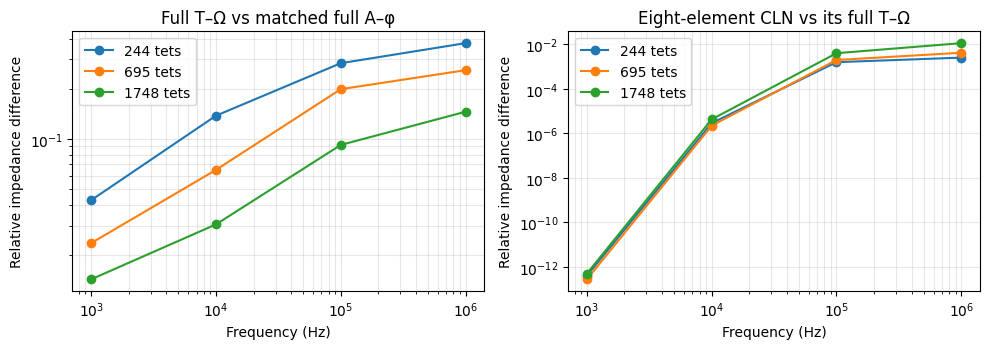

In [6]:
fig, axes = plt.subplots(1,2,figsize=(10,3.6))
for c in sequence:
    r = c["T_Omega_runs"][0]
    f = [x["hz"] for x in r["frequency"]]
    axes[0].loglog(f, [x["cross_form_gap"] for x in r["frequency"]], "o-", label=f"{c['mesh']['ne']} tets")
    axes[1].loglog(f, [x["reduction_error"] for x in r["frequency"]], "o-", label=f"{c['mesh']['ne']} tets")
axes[0].set_title("Full T–Ω vs matched full A–φ")
axes[1].set_title("Eight-element CLN vs its full T–Ω")
for ax in axes:
    ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("Relative impedance difference")
    ax.grid(True,which="both",alpha=.3);ax.legend()
fig.tight_layout();plt.show()

## Coaxial return-path control and limits

The analytic coaxial impedance is the internal Bessel skin-effect impedance plus $s\mu h\ln(b/a)/(2\pi)$. Its DC inductance includes the conductor contribution $\mu h/(8\pi)$ as well. Circular geometry, discretization and skin-layer error remain present in full FEM. A small CLN error cannot remove them. The following comparison is to the analytic full impedance, not to fitted data.

In [7]:
from validate_general_3d_air import oracle
for c in record["cases"]:
    if c["geometry"] == "coax":
        r=c["runs"][0]
        errors=[abs(complex(*x["Z"])/oracle(2j*np.pi*x["hz"])-1) for x in r["frequency"]]
        print("H order",c["H_order"],"maxh(mm)",1000*c["maxh"],"oracle errors (%)",[round(100*x,3) for x in errors])
print("No continuum-accuracy claim is made at 100 kHz or 1 MHz.")

H order 0 maxh(mm) 12.0 oracle errors (%) [0.303, 1.845, 4.281, 8.5]
H order 0 maxh(mm) 8.0 oracle errors (%) [0.304, 1.848, 4.269, 8.455]
H order 1 maxh(mm) 12.0 oracle errors (%) [0.043, 0.242, 1.607, 3.862]
No continuum-accuracy claim is made at 100 kHz or 1 MHz.


## Reproduction and scope

Native cases are produced by `validation/cln3d/tomega_air_study.py --geometry ... --maxh ... --order ... --output ...`. Use the nine parameter sets shown above and preserve each result. `tomega_cross_forms.py` recomputes the six notched A–T controls; `collect_tomega_air.py` collects those genuine runs. Native execution requires NGSolve, SciPy and Radia 5.2.3 with `radia.cohomology`; topology is computed without Gmsh. Source hashes, installed cohomology hash, mesh identities and runtime versions are stored with the evidence. The independent CI checker uses only NumPy and the exported small original matrices.

The small original-matrix check covers the notched 118-tetrahedron cohort. The larger cases are stored native evidence, with independent scientific review pending. Skin layers remain unresolved at the higher frequencies, and even the finest notched full models differ by about 9.2% at 100 kHz and 14.5% at 1 MHz. At positive shift its R2/L3 differences from A–T remain about 19.3%/33.6%; deep differences reach 181%. They are not cross-validated physical elements. This work does not establish an open-boundary model, shell losses, a nonlinear CLN or a multiply connected conducting-current model.

References: [Gross and Kotiuga, *Data structures for geometric and topological aspects of finite element algorithms*, PIER 32, 151–169 (2001)](https://webhomes.maths.ed.ac.uk/~v1ranick/papers/kotiuga2.pdf) explains cochains and discrete duality; [Stockrahm, Lahtinen, Kangas and Kotiuga, *Cuts for 3-D magnetic scalar potentials* (2019)](https://arxiv.org/abs/1902.01124) discusses magnetic scalar cuts. The native experiments and energy recursion here are self-authored implementations, with the stated numerical limits.